In [25]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns



In [16]:
#with open("aapl.us.txt" , "r" , encoding="utf-8") as f:
 #      tetx= line.strip()
  #      print(tetx)

In [17]:
df = pd.read_csv("aapl.us.txt" , parse_dates=['Date'] , index_col='Date')
df.head()

,Open,High,Low,Close,Volume,OpenInt
Date,,,,,,
1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


In [24]:
#dropping 0 values
if 'OpenInt' in df.columns:
    df.drop(columns=['OpenInt'] , inplace=True)

print("Column dropped")


Column dropped


**Exploratory Analysis**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8364 entries, 1984-09-07 to 2017-11-10
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    8364 non-null   float64
 1   High    8364 non-null   float64
 2   Low     8364 non-null   float64
 3   Close   8364 non-null   float64
 4   Volume  8364 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 392.1 KB


In [20]:
print(df.isnull().sum())

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [21]:
display(df.describe())

,Open,High,Low,Close,Volume
count,8364.000000,8364.000000,8364.000000,8364.000000,8.364000e+03
mean,22.284350,22.495867,22.054244,22.281018,1.066416e+08
std,37.763402,38.057733,37.447432,37.764469,9.935187e+07
min,0.233050,0.235640,0.230510,0.230510,0.000000e+00
25%,1.137100,1.164200,1.112800,1.137100,4.384365e+07
50%,1.632800,1.663400,1.600600,1.628250,7.481383e+07
75%,23.739000,23.930500,23.335750,23.694500,1.320534e+08
max,175.110000,175.610000,174.270000,175.610000,2.069770e+09


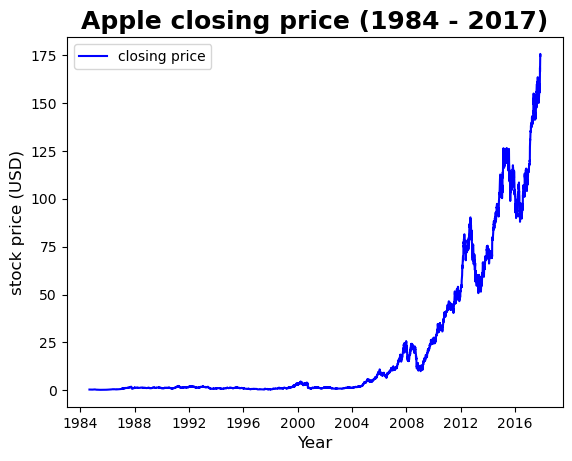

In [26]:
#price tremd over time
plt.Figure(figsize=(14, 6))
plt.plot(df.index,df['Close'] , color="blue", label="closing price")
plt.title("Apple closing price (1984 - 2017)" , fontsize=18, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("stock price (USD)", fontsize=12)
plt.legend()
plt.show()

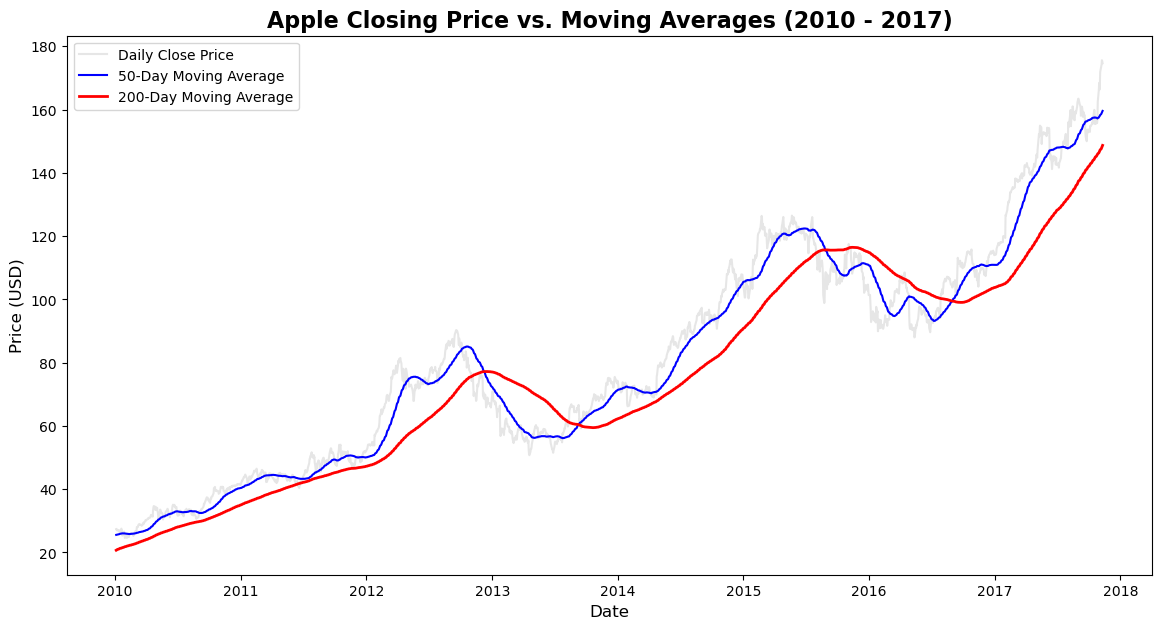

In [28]:
#Simple Moving Average (SMA)
#50-day and 200 day moving avrage
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

#more recent (2010>>>)
df_recent = df.loc['2010':]

plt.figure(figsize=(14, 7))
plt.plot(df_recent.index, df_recent['Close'], label='Daily Close Price', color='gainsboro', alpha=0.7)
plt.plot(df_recent.index, df_recent['MA50'], label='50-Day Moving Average', color='blue', linewidth=1.5)
plt.plot(df_recent.index, df_recent['MA200'], label='200-Day Moving Average', color='red', linewidth=2)

plt.title('Apple Closing Price vs. Moving Averages (2010 - 2017)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.show()

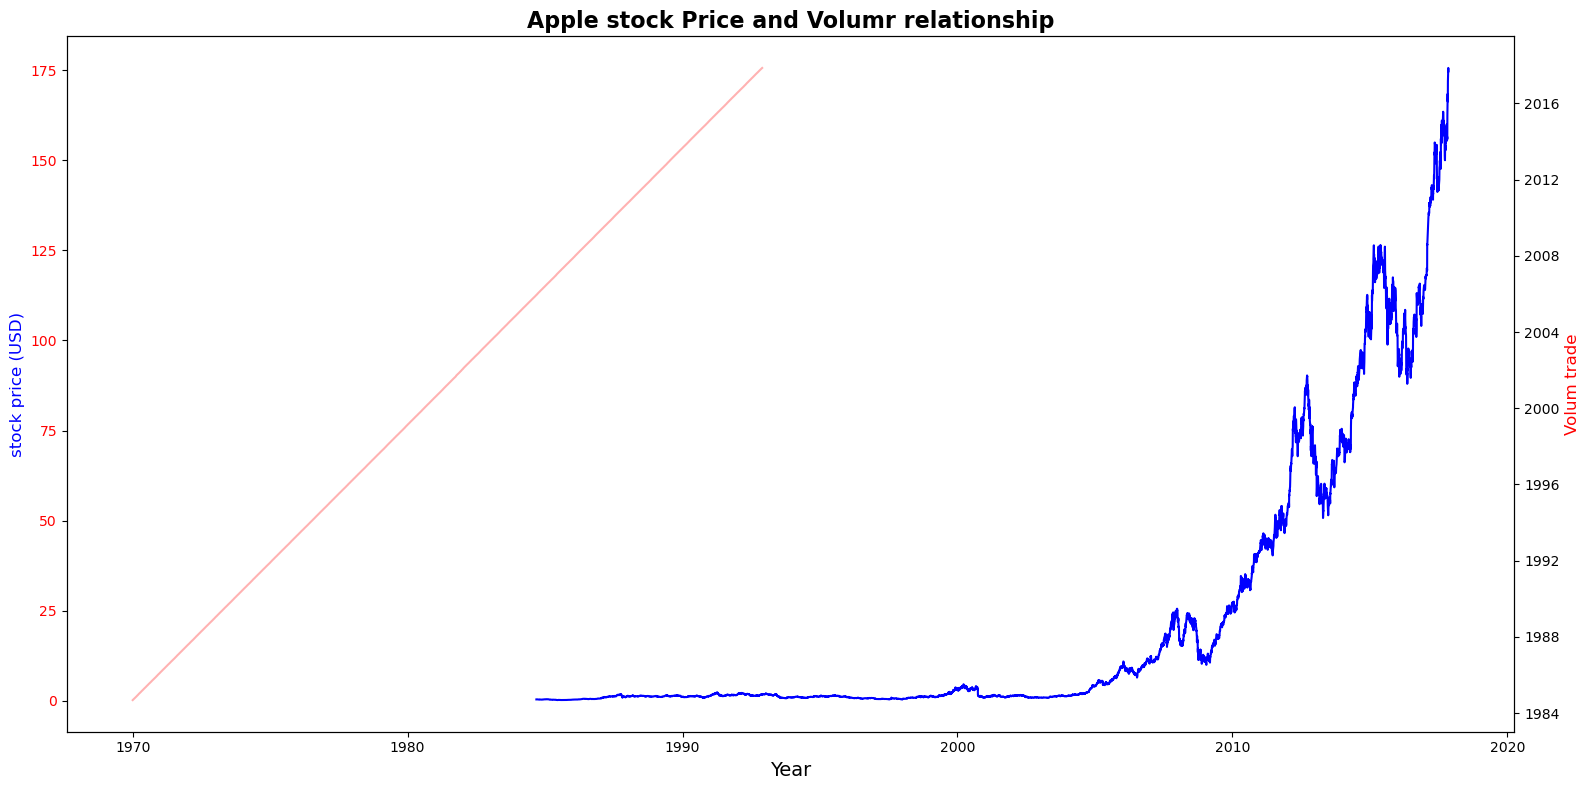

In [32]:
#volum VS price 
fig , ax1 = plt.subplots(figsize=(16, 8))

#plot closing price on the left Y-axis
ax1.set_xlabel("Year" , fontsize=14)
ax1.set_ylabel("stock price (USD)" , color="blue" , fontsize=12)
ax1.plot(df.index, df['Close'] , color='blue' , label='close price')
ax1.tick_params(axis='y', labelcolor='blue')

#Y-axis for volume sharing the same Xs
ax2=ax1.twinx()
ax2.set_ylabel("Volum trade" , color='red' , fontsize=12)
ax2.plot(df.index , color='red' , alpha=0.3 , label='Volume')
ax1.tick_params(axis='y', labelcolor='red')

plt.title("Apple stock Price and Volumr relationship" , fontsize=16 , fontweight='bold')
fig.tight_layout()
plt.show()